<a href="https://colab.research.google.com/github/SIMETHY/HR-Attrition-Prediction/blob/main/HR_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HR Attrition Prediction(Classification)**

# **Problem Statement**

Employee attrition is a critical issue for organizations, leading to increased hiring costs,
productivity loss, and reduced employee morale.
In this project, the goal is to build a Machine Learning classification model that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:
  - Age
  - Salary
  - Job Role
  - Job Satisfaction
  - Work Experience
  - Overtime
  - Work-Life Balance
  - Department
  
Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting employee attrition.

# **Objectives**

The objective of this task is to:
- Understand and explore the HR dataset
- Perform data preprocessing (missing values, duplicates, outliers)
- Conduct Exploratory Data Analysis (EDA)
- Apply encoding and feature scaling
- Train multiple classification algorithms
- Evaluate models using classification metrics
- Perform cross-validation and hyperparameter tuning
- Select the best-performing model

# **Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE

# **Load Data**

In [ ]:
df = pd.read_csv('HR-Employee-Attrition.csv')

In [ ]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# **Basic Checks**

In [ ]:
# Datatypes
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [ ]:
# No of rows and columns
print(df.shape)

(1470, 35)


In [ ]:
# Name of columns
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [ ]:
# information of the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Summary of the dataset
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# **Handling Missing values And Duplicates**

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


There are no null values in the dataset

In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicates in the dataset soo theres

The dataset is clean

# **Seprating columns**

In [ ]:
Cat_cols = df.select_dtypes(include='object')
Cat_cols

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [ ]:
Num_cols = df.select_dtypes(include=['float64','int64']).columns
Num_cols

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

# **Log Transformations**

In [ ]:
cols = ['MonthlyIncome', 'TotalWorkingYears',
        'YearsAtCompany', 'YearsInCurrentRole',
        'YearsSinceLastPromotion']
for col in cols:
    df[col] = np.log1p(df[col])

# **Exploratory Data Analysis**

# **Univariate Analysis**

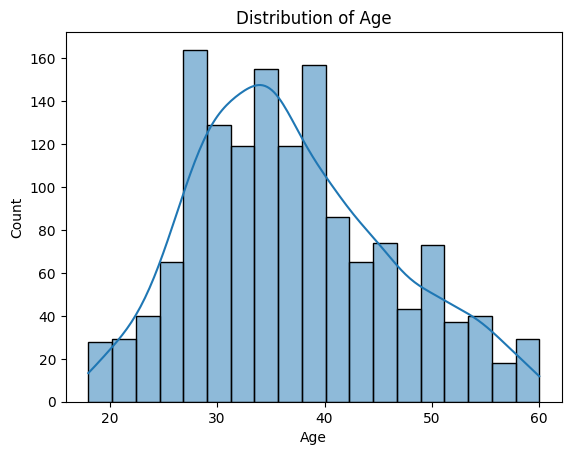

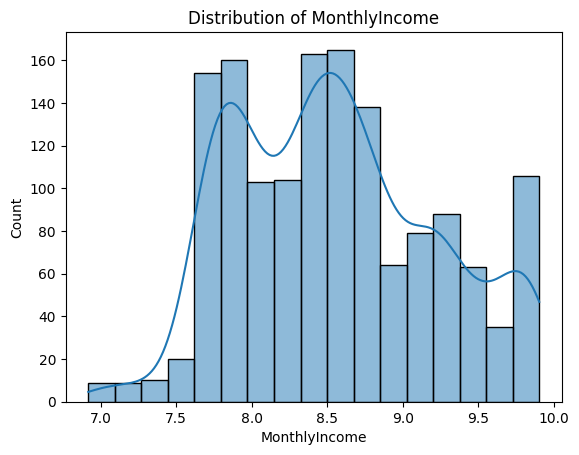

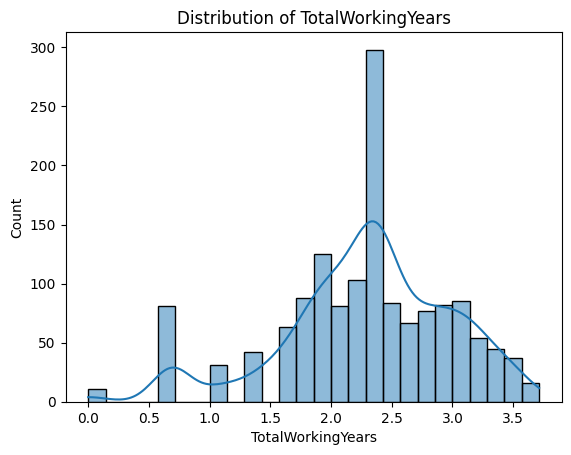

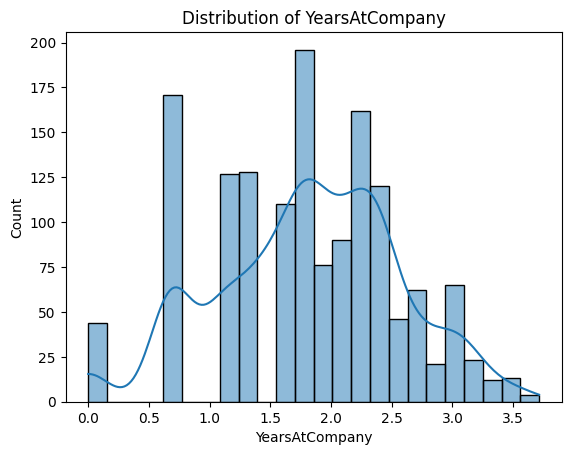

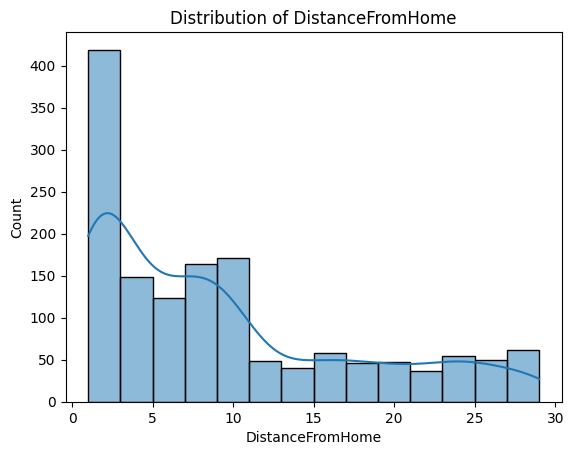

In [ ]:
num_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
            'YearsAtCompany', 'DistanceFromHome']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

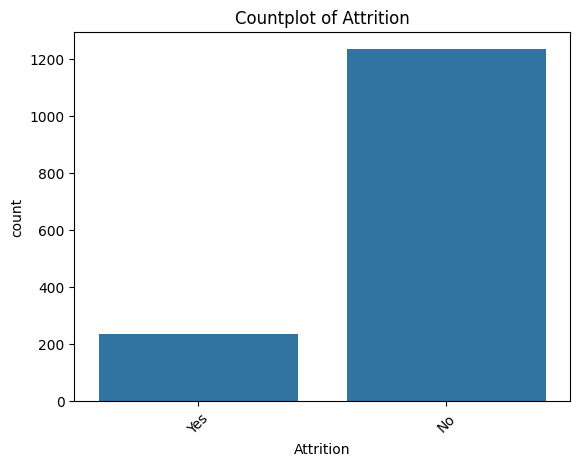

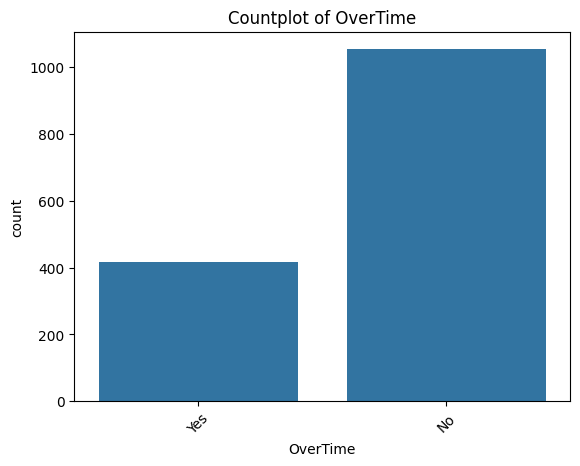

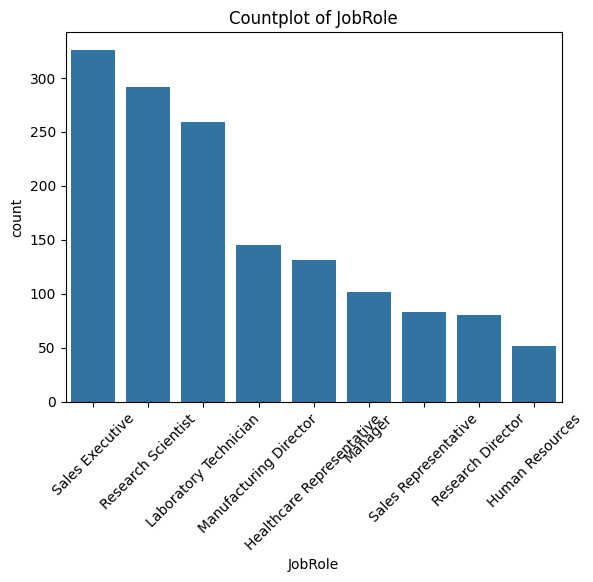

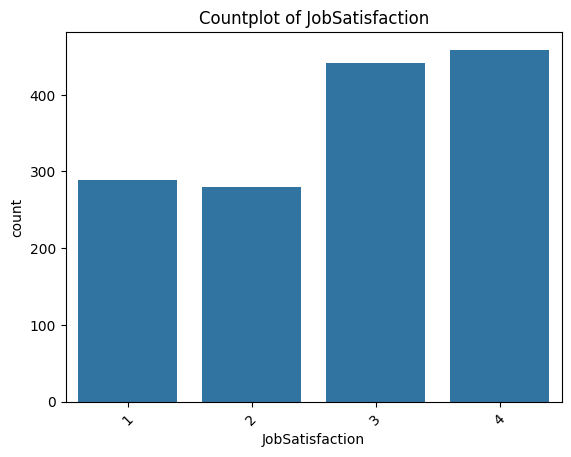

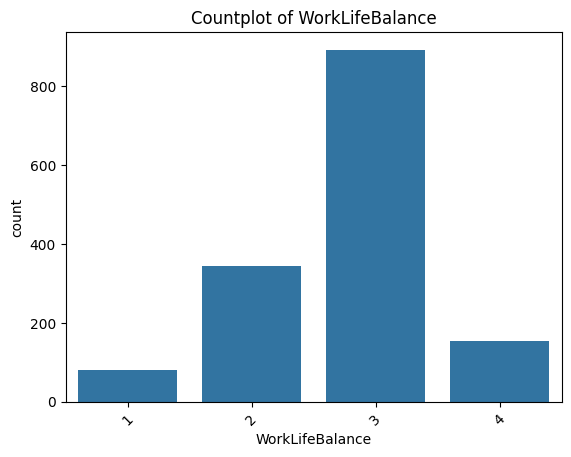

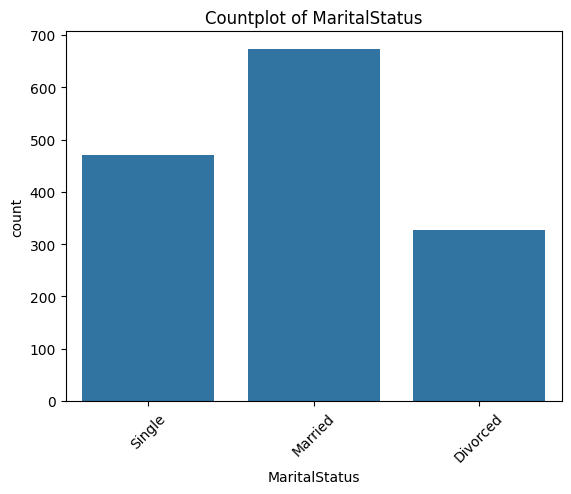

In [ ]:
cat_cols = ['Attrition', 'OverTime', 'JobRole',
            'JobSatisfaction', 'WorkLifeBalance', 'MaritalStatus']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f'Countplot of {col}')
    plt.show()

- Most employees are in the age range of 25–40
- Monthly income is right-skewed (few high earners)
- Majority of employees do not leave (class imbalance)

- Employees doing overtime are significant in number
- Job satisfaction is mostly medium (level 3)
- Work-life balance is average for most employees

- Certain job roles dominate (e.g., Sales Executive, Research Scientist)

# **Bivariate Analysis**

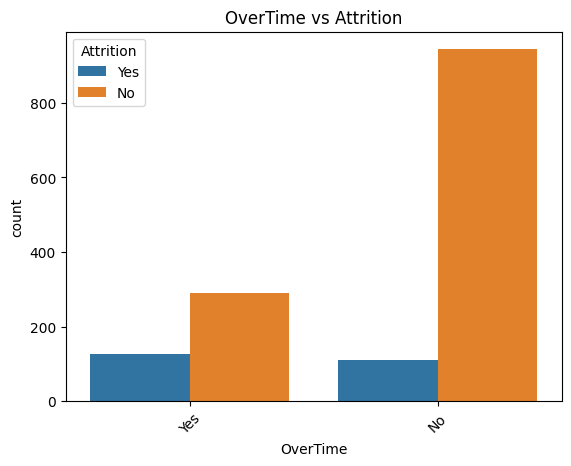

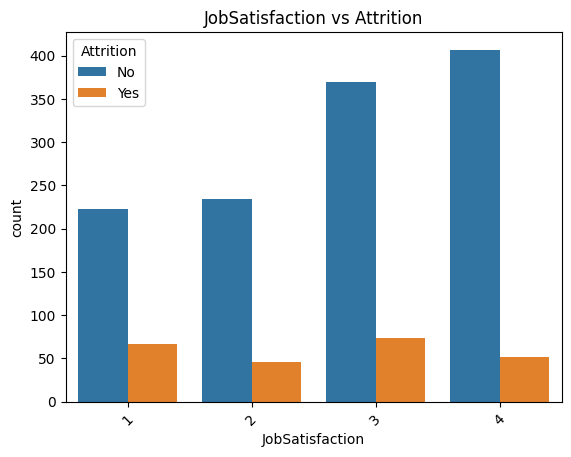

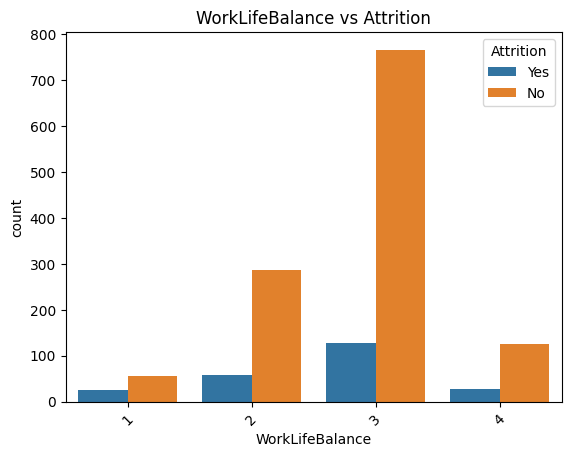

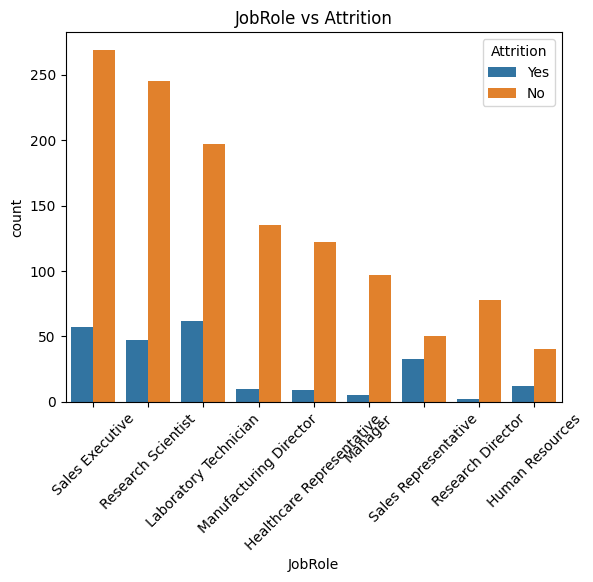

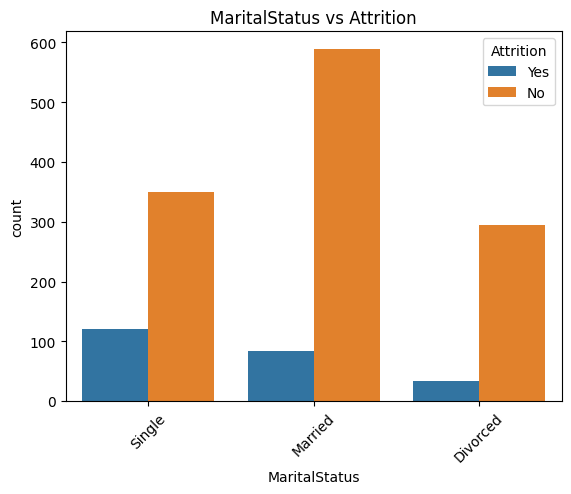

In [ ]:
cat_cols = ['OverTime', 'JobSatisfaction', 'WorkLifeBalance',
            'JobRole', 'MaritalStatus']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, hue='Attrition', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Attrition')
    plt.show()

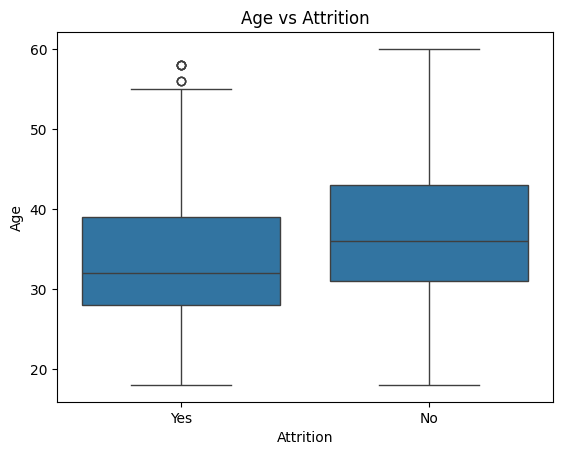

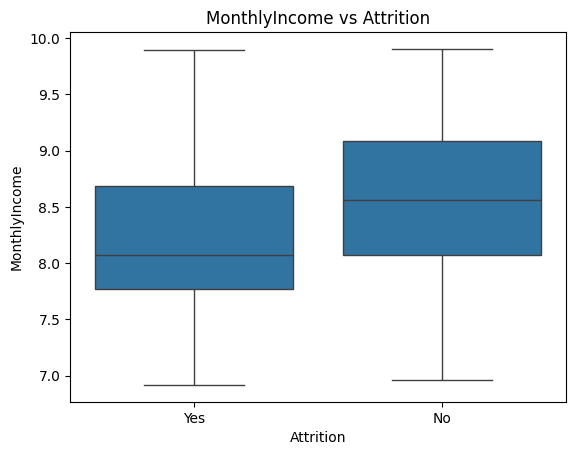

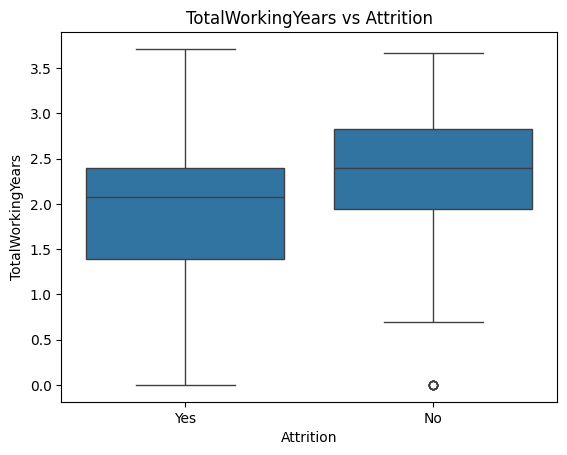

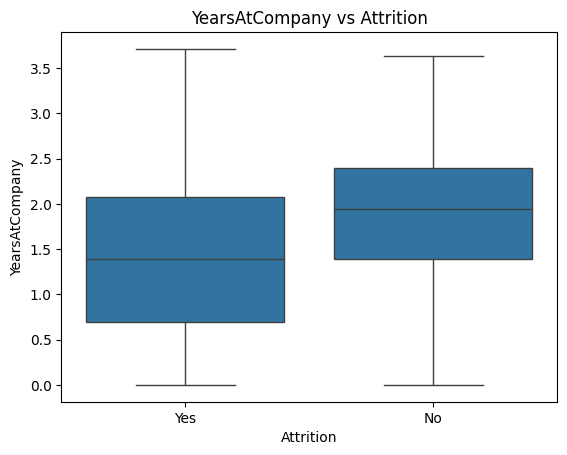

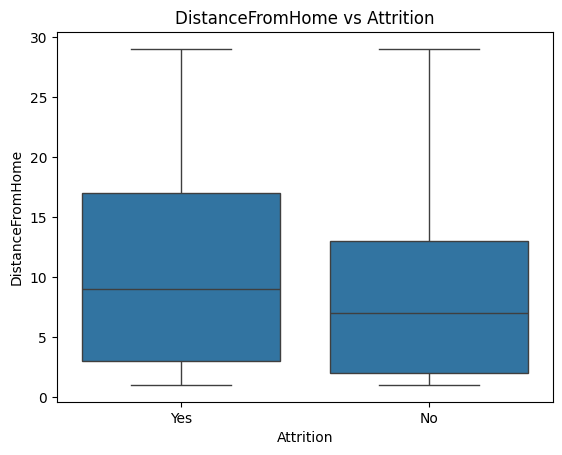

In [ ]:
num_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
            'YearsAtCompany', 'DistanceFromHome']

for col in num_cols:
    plt.figure()
    sns.boxplot(x='Attrition', y=col, data=df)
    plt.title(f'{col} vs Attrition')
    plt.show()

- Employees working overtime are significantly more likely to leave
- Low job satisfaction (1 & 2) shows higher attrition rates
- Poor work-life balance increases attrition

- Employees with lower income tend to leave more
- Employees with fewer years at company show higher attrition
- Younger employees have slightly higher attrition

- Certain job roles (like Sales roles) show higher attrition
- Single employees tend to leave more compared to married ones

# **Multivariate Analysis**

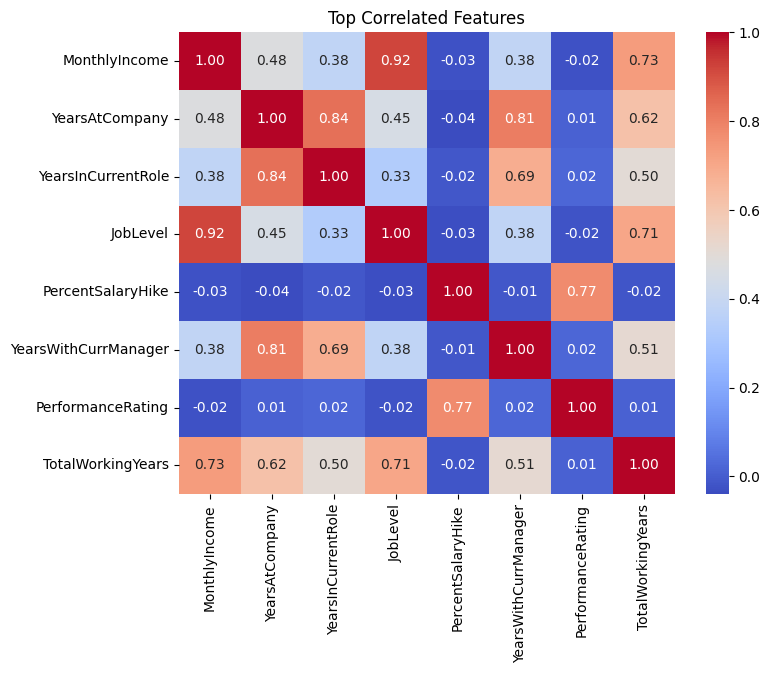

In [ ]:
num_df = df.select_dtypes(include=['float64', 'int64'])
corr = num_df.corr()
# get top correlated pairs
corr_unstack = corr.unstack().sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack < 1]

top_pairs = corr_unstack.head(10) # picking 10 best

# extract columns
cols = list(set([i[0] for i in top_pairs.index] +
                [i[1] for i in top_pairs.index]))

# plot clean heatmap
plt.figure(figsize=(8,6))
sns.heatmap(num_df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Top Correlated Features")
plt.show()

- Strong correlations are observed between experience-related features
- MonthlyIncome increases with TotalWorkingYears and Age
- YearsAtCompany is highly correlated with YearsInCurrentRole
- Most other features show weak relationships
- Therefore, only selected features are visualized for better interpretability

# **Detecting Outlier**

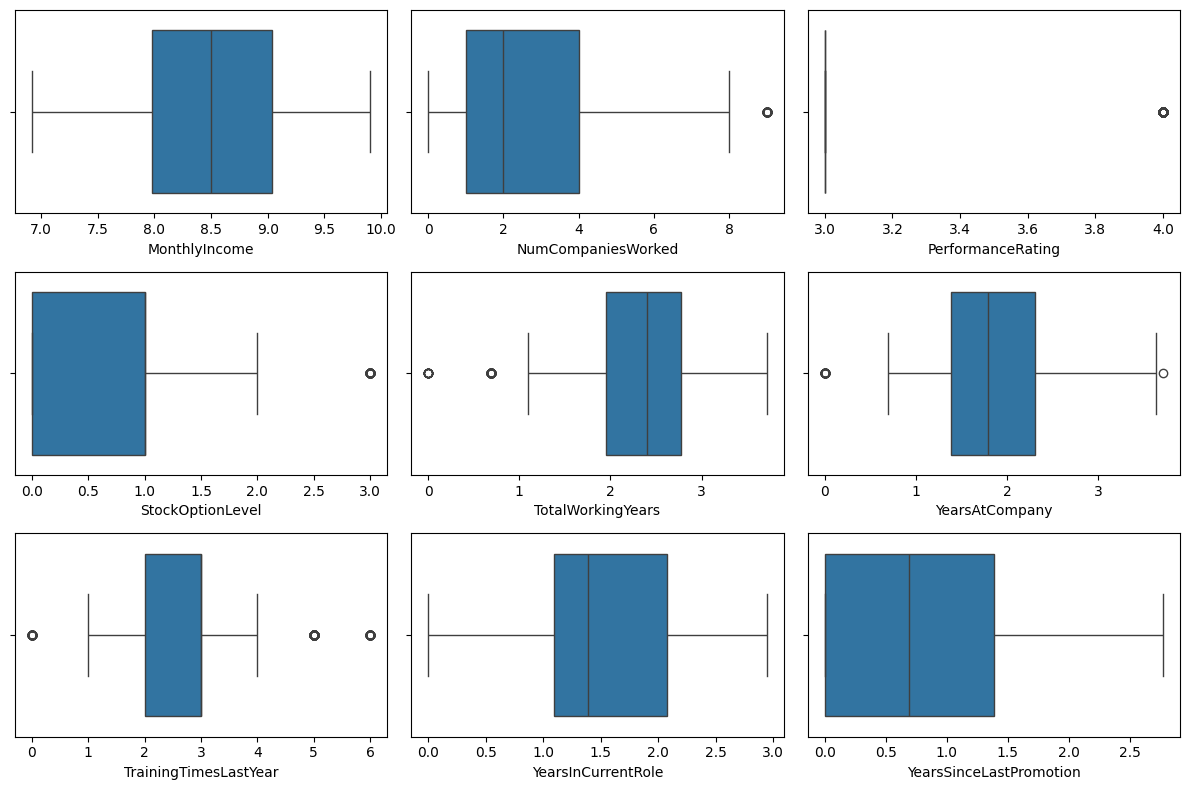

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(12, 8))

sns.boxplot(data=df, x='MonthlyIncome', ax=ax[0,0])
sns.boxplot(data=df, x='NumCompaniesWorked', ax=ax[0,1])
sns.boxplot(data=df, x='PerformanceRating', ax=ax[0,2])

sns.boxplot(data=df, x='StockOptionLevel', ax=ax[1,0])
sns.boxplot(data=df, x='TotalWorkingYears', ax=ax[1,1])
sns.boxplot(data=df, x='YearsAtCompany', ax=ax[1,2])

sns.boxplot(data=df, x='TrainingTimesLastYear', ax=ax[2,0])
sns.boxplot(data=df, x='YearsInCurrentRole', ax=ax[2,1])
sns.boxplot(data=df, x='YearsSinceLastPromotion', ax=ax[2,2])

plt.tight_layout()
plt.show()

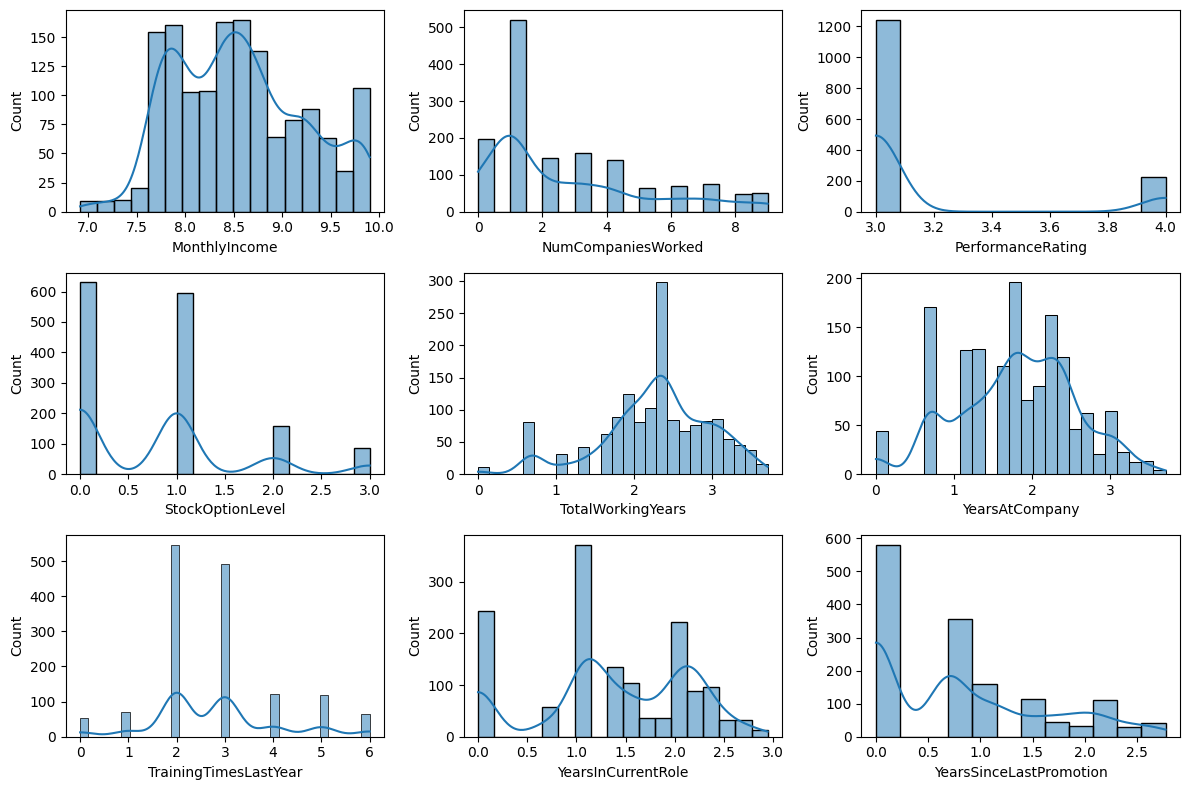

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(12, 8))

sns.histplot(df['MonthlyIncome'], kde=True, ax=ax[0,0])
sns.histplot(df['NumCompaniesWorked'], kde=True, ax=ax[0,1])
sns.histplot(df['PerformanceRating'], kde=True, ax=ax[0,2])

sns.histplot(df['StockOptionLevel'], kde=True, ax=ax[1,0])
sns.histplot(df['TotalWorkingYears'], kde=True, ax=ax[1,1])
sns.histplot(df['YearsAtCompany'], kde=True, ax=ax[1,2])

sns.histplot(df['TrainingTimesLastYear'], kde=True, ax=ax[2,0])
sns.histplot(df['YearsInCurrentRole'], kde=True, ax=ax[2,1])
sns.histplot(df['YearsSinceLastPromotion'], kde=True, ax=ax[2,2])

plt.tight_layout()
plt.show()

- Distribution plots help identify skewness and spread of data
- MonthlyIncome is right-skewed
- Experience-related features show moderate skewness
- Some features are nearly normally distributed

# **Handling Outliers**

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

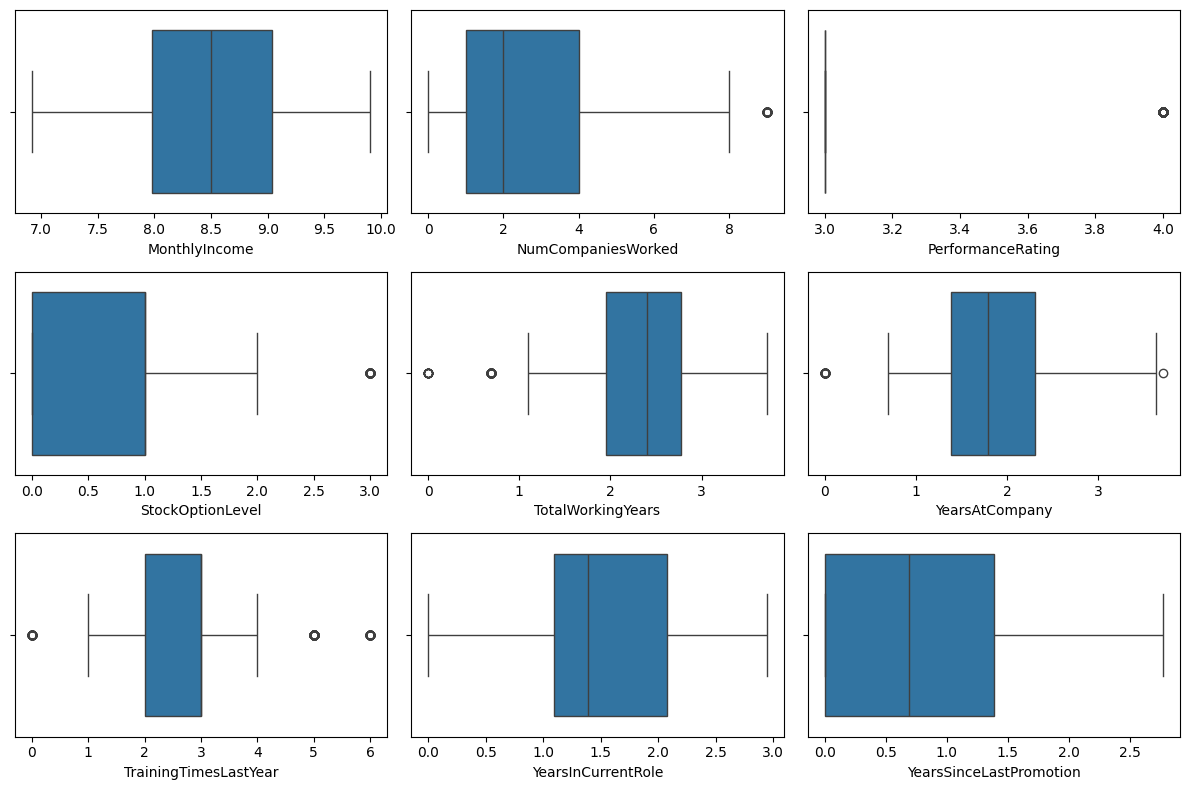

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(12, 8))

sns.boxplot(data=df, x='MonthlyIncome', ax=ax[0,0])
sns.boxplot(data=df, x='NumCompaniesWorked', ax=ax[0,1])
sns.boxplot(data=df, x='PerformanceRating', ax=ax[0,2])

sns.boxplot(data=df, x='StockOptionLevel', ax=ax[1,0])
sns.boxplot(data=df, x='TotalWorkingYears', ax=ax[1,1])
sns.boxplot(data=df, x='YearsAtCompany', ax=ax[1,2])

sns.boxplot(data=df, x='TrainingTimesLastYear', ax=ax[2,0])
sns.boxplot(data=df, x='YearsInCurrentRole', ax=ax[2,1])
sns.boxplot(data=df, x='YearsSinceLastPromotion', ax=ax[2,2])

plt.tight_layout()
plt.show()

- Log transformation was applied to skewed numerical features
- Outliers were handled using IQR-based capping
- Discrete and ordinal features were excluded from outlier treatment
- Remaining extreme values represent valid business scenarios

# **Encoding**

In [ ]:
# Label Encoding target
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])

In [ ]:
# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# **Feature Scaling**

In [ ]:
scaler = StandardScaler()

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_scaled = scaler.fit_transform(X)

# **Train-Test and Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# **Handling Imbalances**

In [ ]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# **Models**

# **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [ ]:
# Evaluate
print("=== Random Forest (Default) ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

=== Random Forest (Default) ===
Confusion Matrix
 [[207  48]
 [ 18  21]]
Accuracy: 0.7755102040816326
Recall: 0.5384615384615384
Precision: 0.30434782608695654
F1 Score: 0.3888888888888889


# **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
# Evaluate
print("=== Decision Tree (Default) ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

=== Decision Tree (Default) ===
Confusion Matrix
 [[225  30]
 [ 27  12]]
Accuracy: 0.8061224489795918
Recall: 0.3076923076923077
Precision: 0.2857142857142857
F1 Score: 0.2962962962962963


**With HyperParameter**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [ ]:
# Evaluate
print("=== Decision Tree With Hyperparameters ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

=== Decision Tree With Hyperparameters ===
Confusion Matrix
 [[228  27]
 [ 26  13]]
Accuracy: 0.8197278911564626
Recall: 0.3333333333333333
Precision: 0.325
F1 Score: 0.3291139240506329


# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)



In [ ]:
# Evaluate
print("=== KNN  ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

=== KNN  ===
Confusion Matrix
 [[168  87]
 [ 15  24]]
Accuracy: 0.6530612244897959
Recall: 0.6153846153846154
Precision: 0.21621621621621623
F1 Score: 0.32


# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Evaluate
print("=== Random Forest (Default) ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

=== Random Forest (Default) ===
Confusion Matrix
 [[225  30]
 [ 27  12]]
Accuracy: 0.8061224489795918
Recall: 0.3076923076923077
Precision: 0.2857142857142857
F1 Score: 0.2962962962962963


**With HyperParameter**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Evaluate
print("=== Random Forest with Hyperparameter ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

=== Random Forest with Hyperparameter ===
Confusion Matrix
 [[250   5]
 [ 31   8]]
Accuracy: 0.8775510204081632
Recall: 0.20512820512820512
Precision: 0.6153846153846154
F1 Score: 0.3076923076923077


# **ROC - AUC**

In [ ]:
from sklearn.metrics import roc_auc_score

print("Logistic ROC:", roc_auc_score(y_test, y_pred_log))
print("Decision Tree ROC:", roc_auc_score(y_test, y_pred_dt))
print("Random Forest ROC:", roc_auc_score(y_test, y_pred_rf))
print("KNN ROC:", roc_auc_score(y_test, y_pred_knn))

Logistic ROC: 0.6751131221719457
Decision Tree ROC: 0.6137254901960785
Random Forest ROC: 0.592760180995475
KNN ROC: 0.63710407239819


# **Perform Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "KNN": knn_model
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    result = cross_val_score(model, X_train, y_train, cv=kfold)

    print(f"{name}:")
    print(result)
    print(f"Mean Accuracy: {np.mean(result):.4f}")
    print("-" * 40)

Logistic Regression:
[0.83673469 0.83887468 0.83375959 0.83375959 0.81074169]
Mean Accuracy: 0.8308
----------------------------------------
Decision Tree:
[0.86734694 0.84910486 0.86445013 0.84910486 0.88491049]
Mean Accuracy: 0.8630
----------------------------------------
Random Forest:
[0.93622449 0.92838875 0.93606138 0.9488491  0.94629156]
Mean Accuracy: 0.9392
----------------------------------------
KNN:
[0.81122449 0.79795396 0.80818414 0.8286445  0.79283887]
Mean Accuracy: 0.8078
----------------------------------------


# **Compare Model Performance**

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn)
    ]
})

comparison = comparison.sort_values(by="F1 Score", ascending=True)

print(comparison)

                 Model  Accuracy    Recall  Precision  F1 Score
2        Random Forest  0.877551  0.205128   0.615385  0.307692
3                  KNN  0.653061  0.615385   0.216216  0.320000
1        Decision Tree  0.819728  0.333333   0.325000  0.329114
0  Logistic Regression  0.775510  0.538462   0.304348  0.388889


# **Best Model**

In [ ]:
best_model = comparison.iloc[0]
print("Best Model:\n", best_model)

Best Model:
 Model        Random Forest
Accuracy          0.877551
Recall            0.205128
Precision         0.615385
F1 Score          0.307692
Name: 2, dtype: object


# **Conclusion**

### Best Model Selection

- The models were compared using Accuracy, Precision, Recall, and F1 Score
- F1 Score was considered the primary metric due to class imbalance
- Among all models, **Random Forest** performed the best

### Reason:
- It achieved the highest F1 Score
- It balanced precision and recall effectively
- It captured complex relationships in the data better than other models